**Group information**

| Family name | First name | Email address |
| ----------- | ---------- | ------------- |
|             |            |               |
|             |            |               |
|             |            |               |

# Network - Solutions

This work focuses on the automated extraction of information from a collection of historical French military maps covering mainland France between 1820 and 1866. The dataset contains 403 colour rasters of dimensions $3 \times 1000 \times 1000$, provided in GeoTIFF format and projected in the Lambert-93 coordinate system (EPSG:2154). The maps represent the *département* of *Bouches-du-Rhône* at a scale of $1:40,000$, with each raster corresponding to an area of $4\ \text{km}^2$. The entire collection has been digitised, georeferenced, and published by the French National Geographical Institute (IGN), and are available through the [BD Etat-Major 40k](https://geoservices.ign.fr/scanhisto) platform. Ground-truth labels are drawn from IGN's manually annotated vectors for a limited number of *départements*, accessible in the [BD Carto Etat-Major](https://geoservices.ign.fr/bdcarto-e) dataset. These annotations are organised into eight semantic categories: buildings, crops, meadows, pastures, specialised crops, forests, water, and roads. The vector data were rasterised to align with the spatial coverage and resolution of the image data.

**Large language models** can be powerful learning tools, but make sure to continue asking questions until you fully understand the produced answer and can judge its correctness. Simply copy-pasting generated code does not contribute to learning and is a waste of your class time.

In [1]:
# Packages
import numpy as np
import pandas as pd
import os
import rasterio
import shutil
import torch
import torchinfo

from captum import attr
from matplotlib import pyplot as plt
from scipy import ndimage
from skimage import color
from sklearn import metrics, preprocessing
from torch import nn, optim, utils
from tqdm import tqdm
from urllib import request

# Device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(device)

# Utilities
classes = {1:'buildings', 2:'crops', 3:'meadows', 4:'pastures', 5:'specialised', 6:'forests', 7:'water', 8:'roads'}

In [ ]:
# Utilities
def download_data():
    if os.getcwd().endswith('/data'):
        print('Data folder already exists')
    else:
        request.urlretrieve('https://www.dropbox.com/scl/fi/728r8otkaao8cm2k891bv/image_data.zip?rlkey=8z6mjfzyrsuac3g9x9q98z7sh&st=m74tez02&dl=1', 'data.zip')
        shutil.unpack_archive('data.zip', 'data')
        os.remove('data.zip')
        os.chdir('data')

def read_raster(file:str, dtype:torch.dtype) -> np.ndarray:
    image = rasterio.open(file).read()
    image = torch.from_numpy(image).type(dtype)
    return image

def plot_raster(image:torch.Tensor, title:str='', cmap:str='gray', figsize=(5, 5)) -> None:
    image   = torch.einsum('dhw -> hwd', image)
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    plt.close()

In [3]:
# Downloads data
os.chdir(os.path.expanduser('~/Dropbox/teaching/image_analysis/3_network/network_practice/image_data'))
# download_data()

**1. Load data:** Load the images, labels, segments and masks using the provided `read_raster` function and format the dataset as a `torch.Tensor` of dimensions $n \times d \times h \times w$. Display a sample of matching training images, labels and segments using the provided `plot_rasters` function.

Note: If processing is too slow on your machine, consider using only part of the dataset.

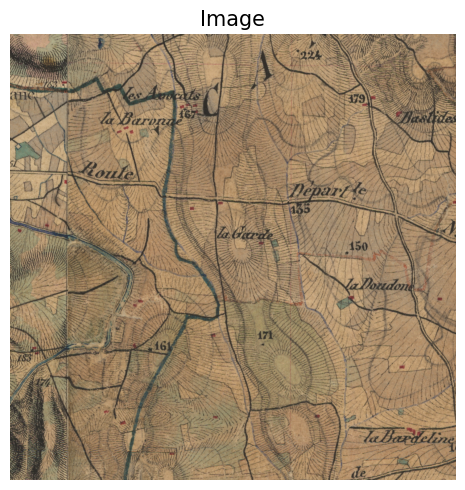

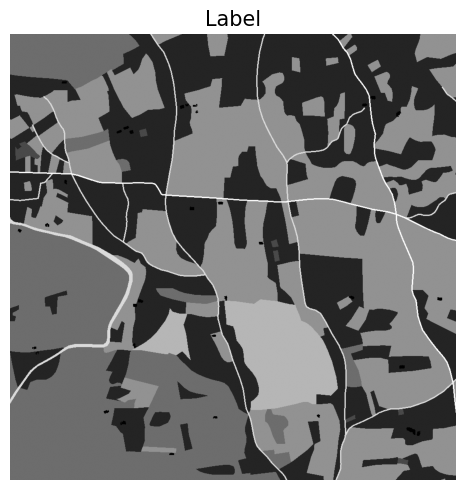

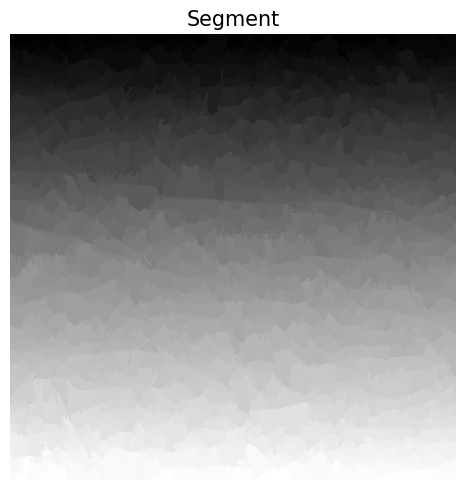

In [4]:
# Loads training data
files    = [file.replace('image_', '') for file in os.listdir('images')]
images   = torch.stack([read_raster(file=f'images/image_{file}', dtype=torch.uint8) for file in files])
labels   = torch.stack([read_raster(file=f'labels/label_{file}', dtype=torch.int64) for file in files])
segments = torch.stack([read_raster(file=f'segments/segment_{file}', dtype=torch.int64) for file in files])
masks    = torch.stack([read_raster(file=f'masks/mask_{file}', dtype=torch.bool) for file in files])
del files

# Displays random images, labels and segments
for i in torch.randint(0, len(images), (1,)):
    plot_raster(image=images[i],   title='Image')
    plot_raster(image=labels[i],   title='Label')
    plot_raster(image=segments[i], title='Segment')

**2. Compute variables:** Define a function that takes an input image, converts its pixel values to the LAB colour space using `color.rgb2lab`, and computes the median and variance of the L, A, and B channels for each super-pixel region (see `ndimage.median` and `ndimage.variance`). The output should be structured as a two-dimensional table, where each row corresponds to a super-pixel and each column represents a variable i.e. median or variance for one of the LAB channels. Apply this transformation to all input images and standardise each variable using `preprocessing.StandardScaler`.

In [5]:
def segment_apply(image:np.ndarray, segment:np.ndarray, function:callable) -> np.ndarray:
    channels  = np.array_split(image, 3, axis=0)
    variables = [function(channel, labels=segment, index=np.unique(segment)) for channel in channels]
    variables = np.column_stack(variables)
    return variables

def compute_variables(image:torch.Tensor, segment:torch.Tensor) -> torch.Tensor:
    image, segment = image.numpy(), segment.numpy()
    image_lab = color.rgb2lab(image, channel_axis=0)
    medians   = segment_apply(image=image_lab, segment=segment, function=ndimage.median)
    variances = segment_apply(image=image_lab, segment=segment, function=ndimage.variance)
    variables = np.column_stack([medians, variances])
    variables = torch.from_numpy(variables)
    return variables

# Computes super-pixel variables
inputs = []
for image, segment in tqdm(zip(images, segments), desc='Computing inputs', total=len(images)):
    inputs.append(compute_variables(image, segment))
inputs = torch.cat(inputs)
scaler = preprocessing.StandardScaler()
inputs = torch.from_numpy(scaler.fit_transform(inputs)).type(torch.float32)

Computing inputs:   0%|          | 0/403 [00:00<?, ?it/s]/Users/goclem/Software/miniconda3/envs/deeplearning/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:646: RuntimeWarning: invalid value encountered in divide
  means = sums / counts
Computing inputs: 100%|██████████| 403/403 [04:27<00:00,  1.51it/s]


**3. Compute labels:** Define a function that takes a label image as input and, for each super-pixel, assigns the most frequent class label within that region. Apply this transformation to the all label images.

In [6]:
def compute_labels(label:torch.Tensor, segment:torch.Tensor, threshold:float=0.75) -> torch.Tensor:
    freqs  = pd.DataFrame({'segment':segment.flatten(), 'label':label.flatten()})
    freqs  = pd.crosstab(freqs.segment, freqs.label)
    subset = freqs.apply(lambda row: np.max(row) > (threshold * np.sum(row)), axis=1)
    target = np.where(subset, freqs.idxmax(axis=1), 0)
    target = torch.from_numpy(target).type(torch.int64)
    return target

# Computes super-pixel labels
outputs = []
for label, segment in tqdm(zip(labels, segments), desc='Computing outputs', total=len(labels)):
    outputs.append(compute_labels(label, segment))
outputs = torch.cat(outputs)

Computing outputs: 100%|██████████| 403/403 [00:26<00:00, 14.93it/s]


**4. Split samples:** Discard super-pixels whose target label is 0 (i.e. undefined class). Partition the remaining data into a training sample (75%) and a test sample (25%). Then, construct PyTorch Dataset (`utils.data.TensorDataset`) and DataLoader (`utils.data.DataLoader`) objects for both samples.

In [7]:
# Removes segments with no label
subset  = torch.where(outputs != 0)
inputs  = inputs[subset]
outputs = outputs[subset]
weights = torch.unique(outputs, return_counts=True)[1]
weights = torch.log1p(weights.max() / weights.float())
del subset

# Draw training and test indices
np.random.seed(0)
samples = np.random.choice(['train', 'test'], len(inputs), p=[0.75, 0.25])

# Initialises data loader
train_dataset = utils.data.TensorDataset(inputs[samples == 'train'], outputs[samples == 'train'])
test_dataset  = utils.data.TensorDataset(inputs[samples == 'test'],  outputs[samples == 'test'])
train_loader  = utils.data.DataLoader(dataset=train_dataset, batch_size=256, shuffle=True)
test_loader   = utils.data.DataLoader(dataset=test_dataset,  batch_size=256, shuffle=False)
del samples, train_dataset

**5. Model structure:** Define a feedforward neural network class using PyTorch. The model takes as input a feature vector and outputs predictions across classes. The model consists of three hidden layers with 64, 32, and 16 units respectively, each followed by a ReLU activation, and ends with a linear output layer. Instantiate the model and print the model architecture.

Note: For numerical stability, PyTorch loss functions expect raw logit scores rather than probability distributions. The softmax transformation is applied internally within the loss function.

In [8]:
# Defines model structure
class SimpleNetwork(nn.Module):

    def __init__(self, n_inputs:int, n_outputs:int) -> None:
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n_inputs, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, n_outputs)
        )

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        y = self.model(x)
        return y
    
# Instantiates model
model = SimpleNetwork(n_inputs=inputs.size(1), n_outputs=len(classes))
torchinfo.summary(model, input_size=inputs.size(), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
SimpleNetwork                            [454473, 8]               --
├─Sequential: 1-1                        [454473, 8]               --
│    └─Linear: 2-1                       [454473, 64]              448
│    └─ReLU: 2-2                         [454473, 64]              --
│    └─Linear: 2-3                       [454473, 32]              2,080
│    └─ReLU: 2-4                         [454473, 32]              --
│    └─Linear: 2-5                       [454473, 16]              528
│    └─ReLU: 2-6                         [454473, 16]              --
│    └─Linear: 2-7                       [454473, 8]               136
Total params: 3,192
Trainable params: 3,192
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 1.45
Input size (MB): 10.91
Forward/backward pass size (MB): 436.29
Params size (MB): 0.01
Estimated Total Size (MB): 447.21

**6. Model training:** Define the appropriate loss function (`nn.CrossEntropyLoss`) and an optimisation algorithm (e.g. `optim.AdamW`).  Write a PyTorch training loop to estimate the model parameters using the training sample, with a maximum of 25 epochs and a learning rate of `1e-3`. Remember to move the model and the batch data to the correct device.

In [9]:
# Define loss and optimiser
model     = model.to(device)
criterion = nn.CrossEntropyLoss(reduction='mean', weight=weights.to(device))
optimiser = optim.AdamW(model.parameters(), lr=1e-3)

In [10]:
# Training loop
n_epochs = 25
for epoch in range(n_epochs):
    model.train()
    tot_obs, tot_loss = 0, 0
    progress = tqdm(train_loader, desc=f'Epoch {epoch+1:02d}/{n_epochs}', unit='batch')
    # Iterate through batches
    for x, y in progress:
        x, y = x.to(device), (y - 1).to(device) # Labels start at 1
        optimiser.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimiser.step()
        # Statistics
        tot_obs  += x.size(0)
        tot_loss += loss.item() * x.size(0)
        progress.set_postfix(loss=f'{tot_loss / tot_obs:.4f}')

del n_epochs, epoch, tot_loss, tot_obs, progress, x, y, logits, loss

# Saves model
torch.save(model.state_dict(), 'landuse_model.pth')

Epoch 25/25: 100%|██████████| 1332/1332 [00:08<00:00, 152.62batch/s, loss=0.6533]


**7. Model performance:** Write a PyTorch evaluation loop to assess the model's generalisation performance on the test sample. Interpret the results using `metrics.classification_report` and `metrics.confusion_matrix`.

Test: 100%|██████████| 444/444 [00:01<00:00, 379.21batch/s, loss=0.6581]


              precision    recall  f1-score   support

   buildings       0.89      0.99      0.94      4359
       crops       0.72      0.77      0.74     36937
     meadows       0.52      0.74      0.61      2037
    pastures       0.79      0.62      0.69     34897
 specialised       0.53      0.59      0.56     13906
     forests       0.85      0.90      0.87     16517
       water       0.78      0.91      0.84      4845
       roads       0.00      0.00      0.00        73

    accuracy                           0.73    113571
   macro avg       0.63      0.69      0.66    113571
weighted avg       0.74      0.73      0.73    113571



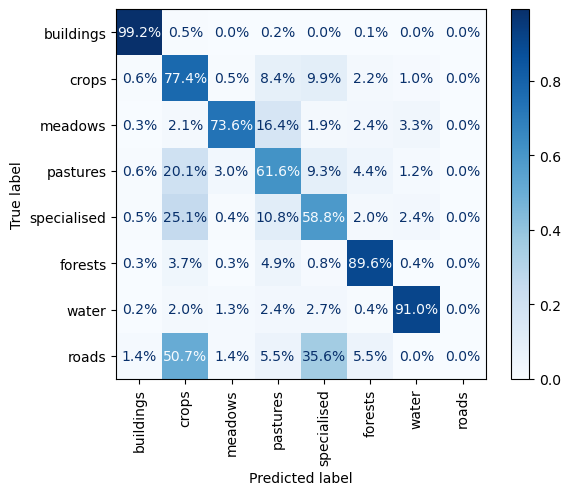

In [11]:
# Loads pre-trained model
# model.load_state_dict(torch.load('landuse_model.pth', weights_only=False, map_location=device))

# Evaluation loop
P_test = []
model.eval()
tot_loss, tot_obs = 0, 0
progress = tqdm(test_loader, desc='Test', unit='batch')
# Iterate through batches
with torch.no_grad():
    for x, y in progress:
        x, y = x.to(device), (y - 1).to(device)
        logits = model(x)
        loss   = criterion(logits, y)
        P_test.append(torch.softmax(logits, dim=1))
        # Statistics
        tot_obs  += x.size(0)
        tot_loss += loss.item() * x.size(0)
        progress.set_postfix(loss=f'{tot_loss / tot_obs:.4f}')

# Formats predictions
Y_test  = test_dataset[:][1] - 1 # Labels start at 1
P_test  = torch.cat(P_test).detach().cpu()
Yh_test = torch.argmax(P_test, dim=1).detach().cpu()

# Computes metrics
print(metrics.classification_report(Y_test, Yh_test, target_names=classes.values(), zero_division=0))
metrics.ConfusionMatrixDisplay.from_predictions(Y_test, Yh_test, display_labels=classes.values(), normalize='true', values_format='.1%', cmap='Blues', xticks_rotation='vertical')

**8. Variable importance:** Using the `attr.IntegratedGradients` function, compute local variable importance on the test sample. Aggregate the results across all observations and display them as a bar plot. Which variables are the most important for the classification?

Test: 100%|██████████| 444/444 [01:22<00:00,  5.37batch/s]


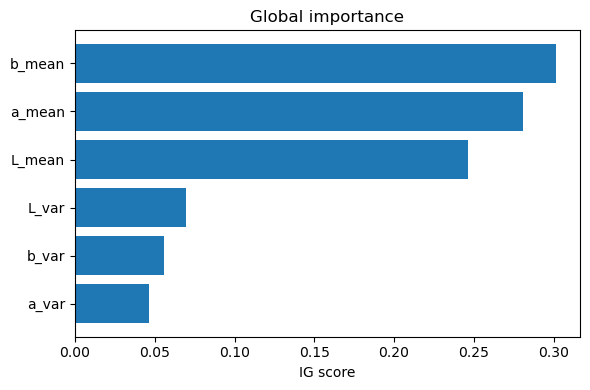

In [19]:
explain_ig    = attr.IntegratedGradients(model.to('cpu'))
featimp_local = []
for x, y in tqdm(test_loader, desc='Test', unit='batch'):
    featimp_local.append(explain_ig.attribute(inputs=x, baselines=torch.zeros_like(x), target=(y - 1)))
featimp_local = torch.cat(featimp_local)

featimp_global = featimp_local.abs().mean(dim=0)
featimp_global = featimp_global / featimp_global.sum()

# Plot
figdata = pd.Series(featimp_global, index=['L_mean', 'a_mean', 'b_mean', 'L_var', 'a_var', 'b_var']).sort_values(ascending=True)
plt.figure(figsize=(6,4))
plt.barh(figdata.index, figdata.values)
plt.xlabel('IG score')
plt.title('Global importance')
plt.tight_layout()
plt.show()


**9. Prediction:** Implement a function that takes a new input image, applies the trained model to predict class labels, and visualises the resulting predictions as an image. Then, display a sample of test images alongside their corresponding ground-truth labels and predicted label maps for visual comparison.

/Users/goclem/Software/miniconda3/envs/deeplearning/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:646: RuntimeWarning: invalid value encountered in divide
  means = sums / counts


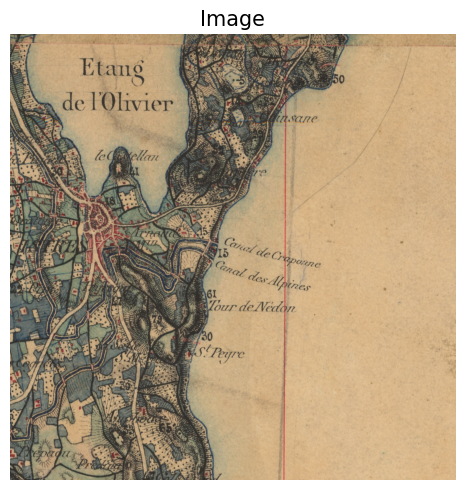

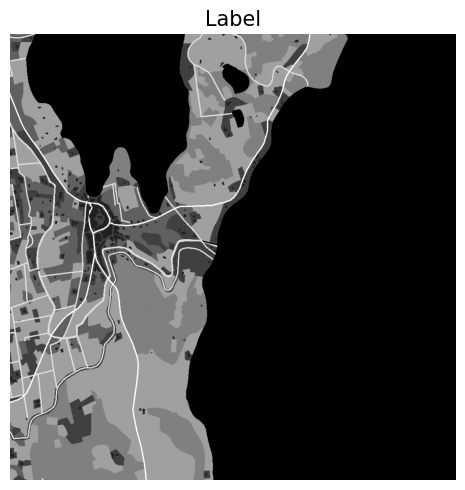

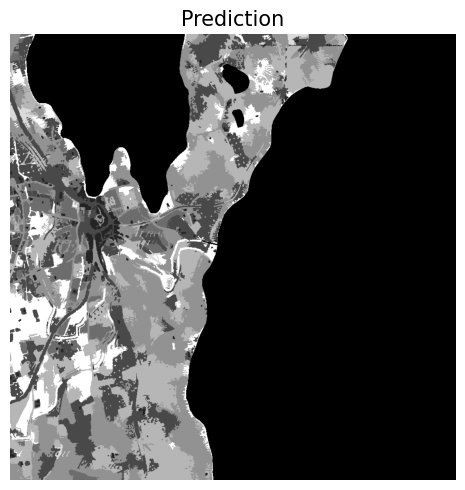

In [20]:
# Predicts test data
def predict_image(image:torch.Tensor, segment:torch.Tensor, mask:torch.Tensor) -> torch.Tensor:
    x  = compute_variables(image, segment)
    x  = torch.from_numpy(scaler.transform(x)).type(torch.float32)
    yh = model(x.to(device))
    yh = torch.softmax(yh, dim=1)
    yh = torch.argmax(yh, dim=1).detach().cpu()
    yh = (yh + 1)[segment - 1]
    yh = torch.where(mask, yh, 0)
    return yh

# Displays labels and predictions
for i in torch.randint(0, len(images), (1,)):
    pred = predict_image(image=images[i], segment=segments[i], mask=masks[i])
    plot_raster(images[i], title='Image')
    plot_raster(labels[i], title='Label')
    plot_raster(pred,      title='Prediction')